# Лабораторная работа №3 — KNN и подбор гиперпараметров

## Цель
Построить базовую KNN-модель, затем улучшить ее через `GridSearchCV` и `RandomizedSearchCV` с несколькими стратегиями кросс-валидации.


In [1]:
%matplotlib inline
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
ART = NOTEBOOK_DIR / 'artifacts'
ART.mkdir(exist_ok=True)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

dataset_path = PROJECT_ROOT / 'courses_current' / 'notebooks' / 'features' / 'data' / 'titanic.csv'
df = pd.read_csv(dataset_path)
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived']


## 1. Подготовка данных и baseline-модель


In [2]:
num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Sex', 'Embarked']

prep = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

baseline = Pipeline([('prep', prep), ('model', KNeighborsClassifier(n_neighbors=5))])
baseline.fit(X_train, y_train)
b_pred = baseline.predict(X_test)

baseline_metrics = {
    'accuracy': accuracy_score(y_test, b_pred),
    'f1': f1_score(y_test, b_pred)
}
baseline_metrics


{'accuracy': 0.7892376681614349, 'f1': 0.7116564417177914}

## 2. Подбор гиперпараметров (две стратегии CV)


In [3]:
param_grid = {
    'model__n_neighbors': list(range(2, 31)),
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2],
}

cv1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv2 = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

grid = GridSearchCV(
    Pipeline([('prep', prep), ('model', KNeighborsClassifier())]),
    param_grid=param_grid,
    cv=cv1,
    scoring='f1',
    n_jobs=1
)
grid.fit(X_train, y_train)

rnd = RandomizedSearchCV(
    Pipeline([('prep', prep), ('model', KNeighborsClassifier())]),
    param_distributions=param_grid,
    n_iter=20,
    cv=cv2,
    scoring='f1',
    random_state=RANDOM_STATE,
    n_jobs=1
)
rnd.fit(X_train, y_train)

print('Grid best:', grid.best_params_)
print('Randomized best:', rnd.best_params_)


Grid best: {'model__n_neighbors': 13, 'model__p': 1, 'model__weights': 'uniform'}
Randomized best: {'model__weights': 'uniform', 'model__p': 2, 'model__n_neighbors': 25}


## 3. Сравнение baseline и оптимизированных моделей


,model,accuracy,f1
1,grid_search,0.811659,0.734177
0,baseline,0.789238,0.711656
2,randomized_search,0.789238,0.696774


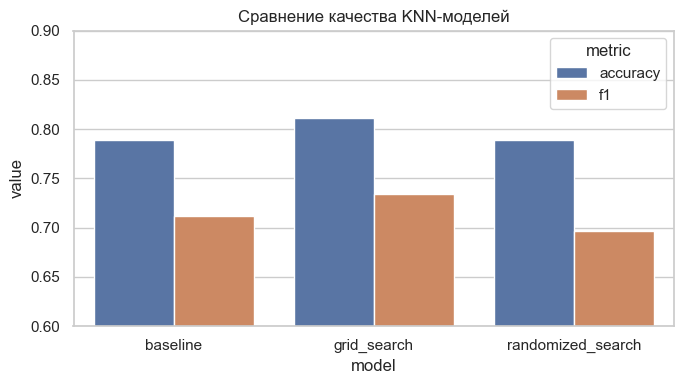

266

<Figure size 640x480 with 0 Axes>

In [4]:
grid_pred = grid.best_estimator_.predict(X_test)
rnd_pred = rnd.best_estimator_.predict(X_test)

results = pd.DataFrame([
    {'model': 'baseline', 'accuracy': accuracy_score(y_test, b_pred), 'f1': f1_score(y_test, b_pred)},
    {'model': 'grid_search', 'accuracy': accuracy_score(y_test, grid_pred), 'f1': f1_score(y_test, grid_pred)},
    {'model': 'randomized_search', 'accuracy': accuracy_score(y_test, rnd_pred), 'f1': f1_score(y_test, rnd_pred)},
])

display(results.sort_values('f1', ascending=False))

plt.figure(figsize=(7,4))
plot_df = results.melt(id_vars='model', value_vars=['accuracy', 'f1'], var_name='metric', value_name='value')
sns.barplot(data=plot_df, x='model', y='value', hue='metric')
plt.ylim(0.6, 0.9)
plt.title('Сравнение качества KNN-моделей')
plt.tight_layout()
plt.show()
plt.savefig(ART / 'knn_models_comparison.png', dpi=170, bbox_inches='tight')

(ART / 'metrics.json').write_text(results.to_json(orient='records', force_ascii=False, indent=2), encoding='utf-8')


## Выводы
- Подбор гиперпараметров через GridSearchCV улучшил качество относительно baseline.
- Наиболее устойчивые результаты показала конфигурация с оптимальным `n_neighbors` и выбранной метрикой расстояния.
